# Explore here

**Definición del problema**

El objetivo es predecir charges en función de las variables fisiológicas y demográficas del cliente (edad, sexo, IMC, hijos, fumador), y region como variable adicional de contexto geográfico/mercado.

**Carga y exploración inicial de los datos**

In [1]:
import pandas as pd

df = pd.read_csv('/workspaces/Proyecto-de-EDA-y-Regresi-n-lineal/data/raw/medical_insurance_cost.csv')

print("Dimensiones:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)
print("\nValores nulos por columna:")
print(df.isnull().sum())
print("\nFilas duplicadas:", df.duplicated().sum())

df.head()

Dimensiones: (1338, 7)

Tipos de datos:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Valores nulos por columna:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Filas duplicadas: 1


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# Eliminar duplicado
df = df.drop_duplicates().reset_index(drop=True)
df.shape

(1337, 7)

**Análisis de variables univariante**

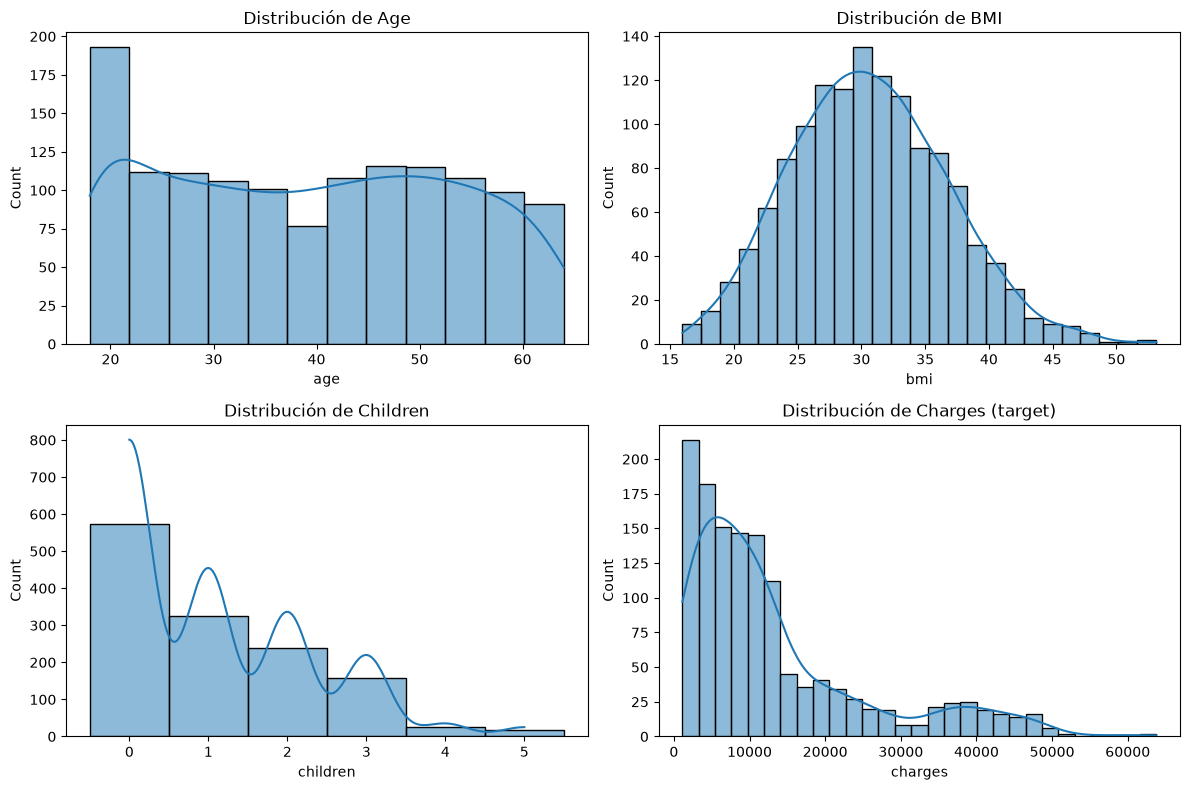

In [4]:
# Distribución de variables numéricas
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df['age'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribución de Age')

sns.histplot(df['bmi'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribución de BMI')

sns.histplot(df['children'], kde=True, ax=axes[1, 0], discrete=True)
axes[1, 0].set_title('Distribución de Children')

sns.histplot(df['charges'], kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Distribución de Charges (target)')

plt.tight_layout()
plt.show()

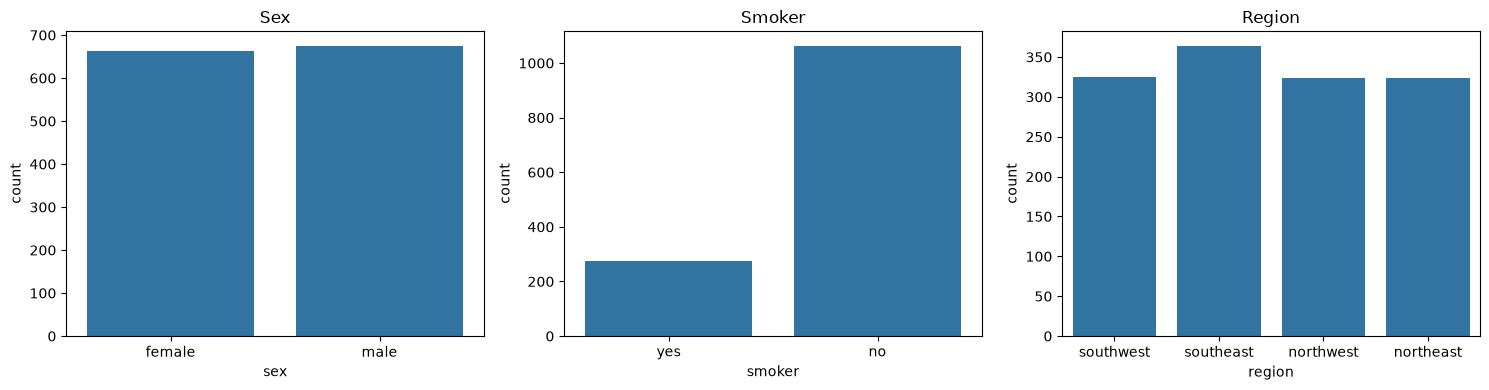

In [5]:
# Distribución de variables categóricas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=df, x='sex', ax=axes[0])
axes[0].set_title('Sex')

sns.countplot(data=df, x='smoker', ax=axes[1])
axes[1].set_title('Smoker')

sns.countplot(data=df, x='region', ax=axes[2])
axes[2].set_title('Region')

plt.tight_layout()
plt.show()

- charges: sesgo a la derecha, el cual es común en este tipo de variables económicas. Vamos a tenerlo en cuenta porque puede afectar los supuestos de la regresión lineal (residuos no normales).
- bmi: distribución normal.
- age: un valor con alta frecuencia a la izquierda (probablemente hay muchos clientes de 18-19 años, el límite inferior de la muestra) y el resto relativamente uniforme.
- sex: balanceado, no debería generar sesgo en el modelo.
- smoker: desbalanceado (menos fumadores) — puede que tenga una relación fuerte con charges.

**Análisis de funciones multivariante**

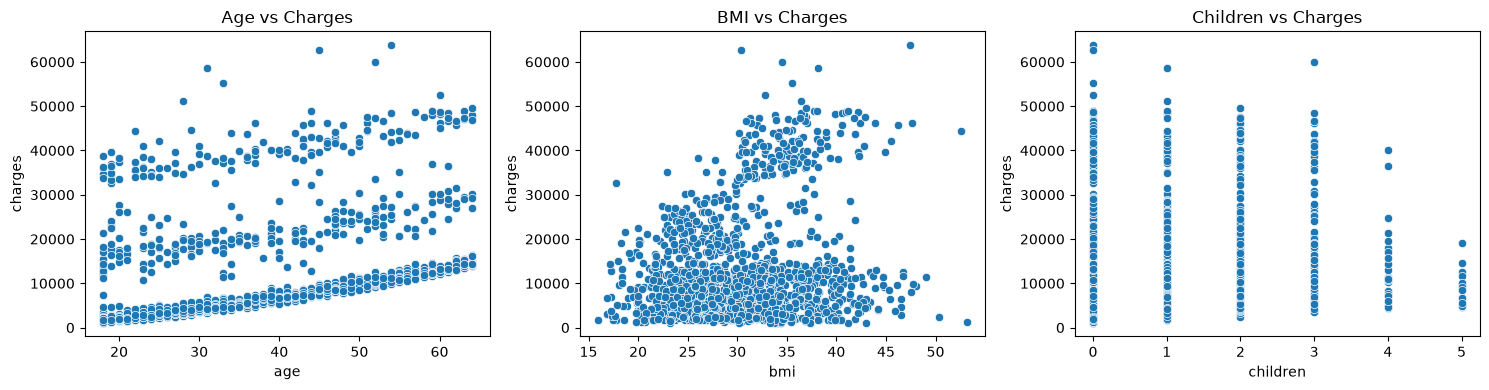

In [6]:
# Relación de variables numéricas con charges
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.scatterplot(data=df, x='age', y='charges', ax=axes[0])
axes[0].set_title('Age vs Charges')

sns.scatterplot(data=df, x='bmi', y='charges', ax=axes[1])
axes[1].set_title('BMI vs Charges')

sns.scatterplot(data=df, x='children', y='charges', ax=axes[2])
axes[2].set_title('Children vs Charges')

plt.tight_layout()
plt.show()

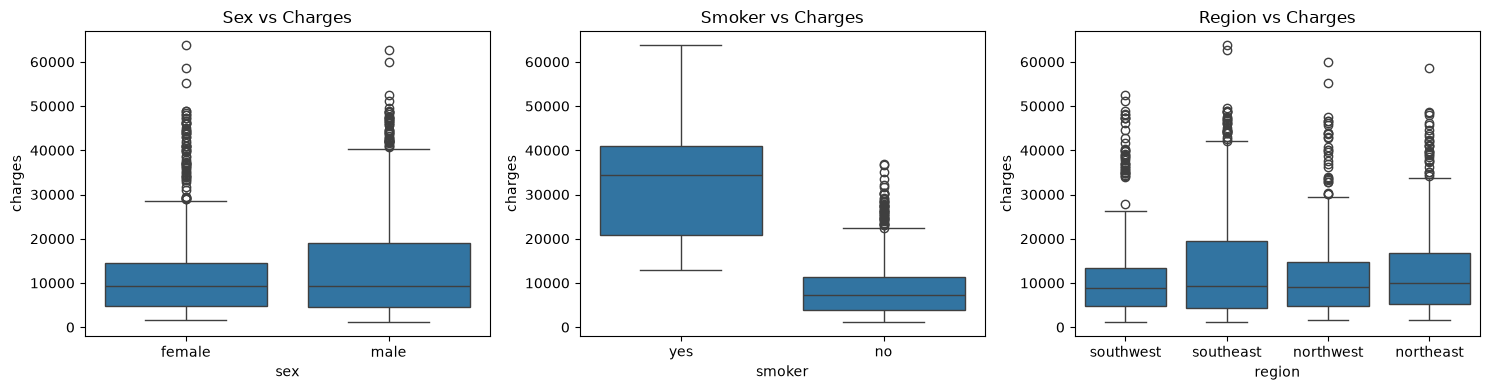

In [7]:
# Relación de variables categóricas con charges
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(data=df, x='sex', y='charges', ax=axes[0])
axes[0].set_title('Sex vs Charges')

sns.boxplot(data=df, x='smoker', y='charges', ax=axes[1])
axes[1].set_title('Smoker vs Charges')

sns.boxplot(data=df, x='region', y='charges', ax=axes[2])
axes[2].set_title('Region vs Charges')

plt.tight_layout()
plt.show()

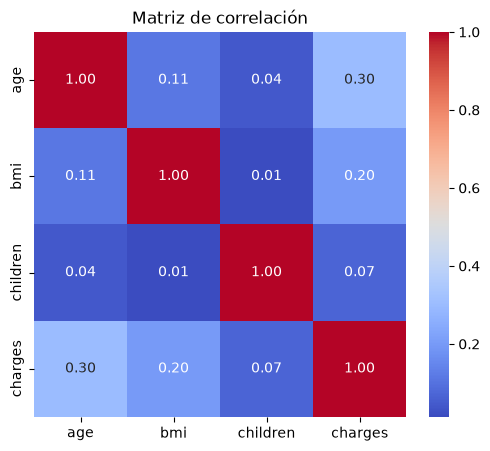

In [9]:
# Matriz de correlación (solo numéricas)
corr = df[['age', 'bmi', 'children', 'charges']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación')
plt.show()

- age vs charges muestra 3 pendientes positivas que nos indican que a mayor edad mayores gastos, sin embargo, al separarse en 3 diagonales diferentes puede que a los grupos de edad les afecte alguna otra variable.
- children vs charges no tiene una tendencia clara, ya que los valores para la cantidad de hijos están dispersos por todo el rango de charges.
- bmi vs charges nos muestra que hay una posible variable que separa las dos agrupaciones grandes de datos.
- sex vs charges no muestra una diferencia tan elevada.
- smoker vs charges es la que más muestra diferencia, la media de no smokers es de 7k aprox. y la de smokers es de 34k aprox., por lo que podemos determinar que de las variables que más aportan a charges.
- region vs charges cuenta con distribuciones parecidas.

Posiblemente (por lógica) hay una correlación alta entre smokers, bmi y charges, por lo que determinaremos si es cierta esta intuición.

In [10]:
# Interacción smoker x bmi
corr_fumadores = df[df['smoker'] == 'yes'][['bmi', 'charges']].corr().iloc[0, 1]
corr_no_fumadores = df[df['smoker'] == 'no'][['bmi', 'charges']].corr().iloc[0, 1]

print(f"Correlación BMI-Charges en fumadores: {corr_fumadores:.3f}")
print(f"Correlación BMI-Charges en no fumadores: {corr_no_fumadores:.3f}")

Correlación BMI-Charges en fumadores: 0.806
Correlación BMI-Charges en no fumadores: 0.084


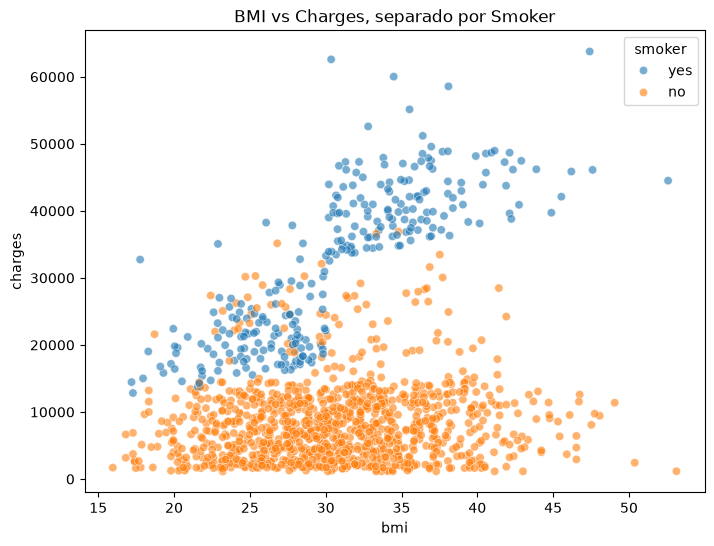

In [11]:
# Interacción con color por smoker
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.6)
plt.title('BMI vs Charges, separado por Smoker')
plt.show()

Esto confirma que bmi por sí sola no nos daba gran información sobre charges, pero con la separación de somkers, nos damos cuenta que los dos grupos separados son de fumadores y no fumadores. Por lo que podemos determinar que smokers es la variable que más aporta a charges y que en combinación con bmi nos da una correlación de lectura mayor.

**Preprocesamiento**

In [12]:
# Codificar variables binarias
df['sex'] = df['sex'].map({'female': 0, 'male': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})

# One-hot encoding para region
df = pd.get_dummies(df, columns=['region'], drop_first=True)

# Interacción bmi x smoker
df['bmi_smoker'] = df['bmi'] * df['smoker']

df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_smoker
0,19,0,27.900,0,1,16884.92400,False,False,True,27.9
1,18,1,33.770,1,0,1725.55230,False,True,False,0.0
2,28,1,33.000,3,0,4449.46200,False,True,False,0.0
3,33,1,22.705,0,0,21984.47061,True,False,False,0.0
4,32,1,28.880,0,0,3866.85520,True,False,False,0.0


**Train/Test split**

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['charges'])
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (1069, 9)
Test: (268, 9)


In [14]:
# Modelo base de regresión lineal
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Coeficientes del modelo
coeficientes = pd.DataFrame({
    'variable': X_train.columns,
    'coeficiente': modelo.coef_
}).sort_values(by='coeficiente', key=abs, ascending=False)

print("Intercepto:", modelo.intercept_)
print()
print(coeficientes)

Intercepto: -1836.083305961838

           variable   coeficiente
4            smoker -21687.830077
8        bmi_smoker   1476.603942
6  region_southeast   -895.669808
7  region_southwest   -884.564628
1               sex   -647.366040
3          children    570.041605
5  region_northwest   -438.161448
0               age    259.044014
2               bmi     12.491983


Esto nos demuestra que fumar solo ya aumenta el costo, pero fumar combinado con BMI alto dispara el costo de forma mucho más fuerte. age y bmi con efecto positivo pequeño, 
region con efectos menores (confirma que aporta poco, como vimos en los boxplots), y children con un efecto positivo moderado.

**Evaluación del modelo**

In [16]:
# Métricas de evaluación
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

y_train_pred = modelo.predict(X_train)
y_test_pred = modelo.predict(X_test)

print("Train")
print("R²:", r2_score(y_train, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("MAE:", mean_absolute_error(y_train, y_train_pred))

print("\nTest")
print("R²:", r2_score(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("MAE:", mean_absolute_error(y_test, y_test_pred))

Train
R²: 0.8247283224158267
RMSE: 4898.7002273868775
MAE: 2967.9824006282292

Test
R²: 0.8862045574393044
RMSE: 4572.811239354674
MAE: 2828.9737471039475


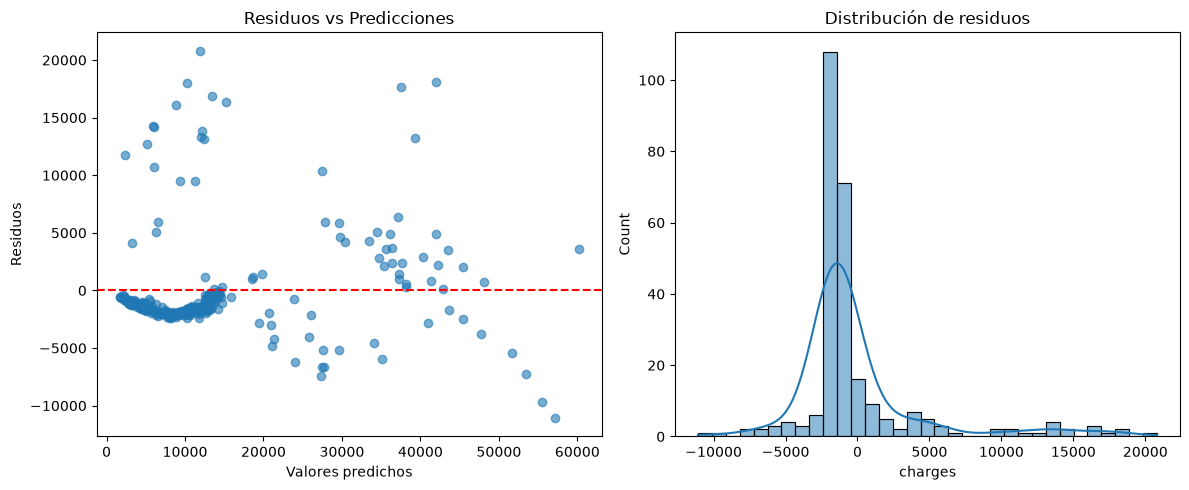

In [17]:
# Análisis de residuos
residuos = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test_pred, residuos, alpha=0.6)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Valores predichos')
axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs Predicciones')

sns.histplot(residuos, kde=True, ax=axes[1])
axes[1].set_title('Distribución de residuos')

plt.tight_layout()
plt.show()

Para predicciones de costos bajos los residuos están sesgados levemente negativos y agrupados, pero para predicciones medias altas hay muchos residuos positivos grandes, lo cual puede indicar que el modelo no captura correctamente los elementos no lineales. Además, el modelo tiene una distribución de residuos que tiene una cola larga a la derecha, por lo que falla en las predicciones altas.

**Mejora del modelo**

In [19]:
# Feature de umbral de obesidad + interacción con smoker
df['obeso'] = (df['bmi'] >= 30).astype(int)
df['obeso_smoker'] = df['obeso'] * df['smoker']

# Volvemos a hacer el split con las nuevas columnas
X = df.drop(columns=['charges'])
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Reentrenamos el modelo
modelo2 = LinearRegression()
modelo2.fit(X_train, y_train)

y_train_pred2 = modelo2.predict(X_train)
y_test_pred2 = modelo2.predict(X_test)

print("Train")
print("R²:", r2_score(y_train, y_train_pred2))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred2)))
print("MAE:", mean_absolute_error(y_train, y_train_pred2))

print("\nTest")
print("R²:", r2_score(y_test, y_test_pred2))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred2)))
print("MAE:", mean_absolute_error(y_test, y_test_pred2))

coeficientes2 = pd.DataFrame({
    'variable': X_train.columns,
    'coeficiente': modelo2.coef_
}).sort_values(by='coeficiente', key=abs, ascending=False)

print("\nIntercepto:", modelo2.intercept_)
print(coeficientes2)

Train
R²: 0.8530710824988325
RMSE: 4485.167139666902
MAE: 2386.9865829663017

Test
R²: 0.9091688217685012
RMSE: 4085.435081363527
MAE: 2276.4547139959172

Intercepto: -977.0717139510853
            variable   coeficiente
10      obeso_smoker  14352.667155
7   region_southwest  -1093.753379
6   region_southeast   -626.399328
9              obeso    579.247487
1                sex   -572.854351
3           children    565.921911
8         bmi_smoker    535.545661
4             smoker   -380.335940
0                age    260.242265
5   region_northwest   -231.965943
2                bmi    -30.258770


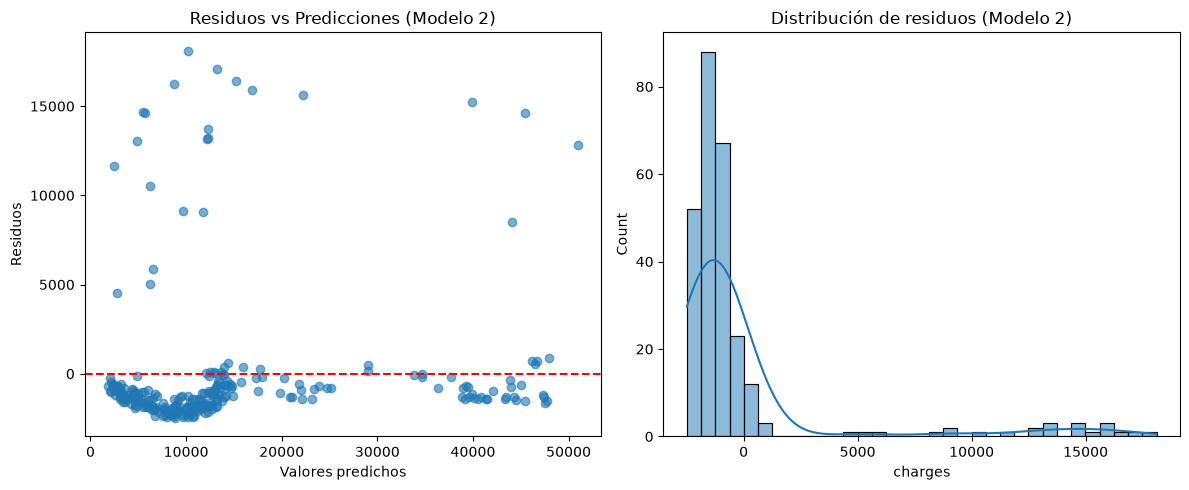

In [20]:
# Análisis de residuos del modelo 2
residuos2 = y_test - y_test_pred2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test_pred2, residuos2, alpha=0.6)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Valores predichos')
axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs Predicciones (Modelo 2)')

sns.histplot(residuos2, kde=True, ax=axes[1])
axes[1].set_title('Distribución de residuos (Modelo 2)')

plt.tight_layout()
plt.show()

Podemos ver que la mayoría de los residuos ahora están mucho más concentrados cerca de cero, sin embargo, en el scatter de "Residuos vs Predicciones" todavía se ve un grupo separado de residuos positivos grandes (entre +5,000 y +18,000) que aparece disperso a lo largo de casi todo el rango de predicciones, no solo en un extremo. Esto es una señal de que todavía falta una variable o interacción que explique por qué el modelo subestima sistemáticamente a ese subgrupo de clientes.

In [21]:
# Modelo con log(charges) como target
y_log = np.log1p(df['charges'])  # log(1 + charges), evita problemas si hubiera charges=0

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

modelo3 = LinearRegression()
modelo3.fit(X_train, y_train_log)

# Predicciones en escala log, revertidas a escala original
y_train_pred3 = np.expm1(modelo3.predict(X_train))
y_test_pred3 = np.expm1(modelo3.predict(X_test))

# y_train/y_test originales (no log) para comparar en $ reales
y_train_real = df.loc[X_train.index, 'charges']
y_test_real = df.loc[X_test.index, 'charges']

print("Train")
print("R²:", r2_score(y_train_real, y_train_pred3))
print("RMSE:", np.sqrt(mean_squared_error(y_train_real, y_train_pred3)))
print("MAE:", mean_absolute_error(y_train_real, y_train_pred3))

print("\nTest")
print("R²:", r2_score(y_test_real, y_test_pred3))
print("RMSE:", np.sqrt(mean_squared_error(y_test_real, y_test_pred3)))
print("MAE:", mean_absolute_error(y_test_real, y_test_pred3))

Train
R²: 0.4146021096131599
RMSE: 8952.62861126302
MAE: 4108.076451120135

Test
R²: 0.6567121712354878
RMSE: 7942.368679870109
MAE: 3981.5376835471043


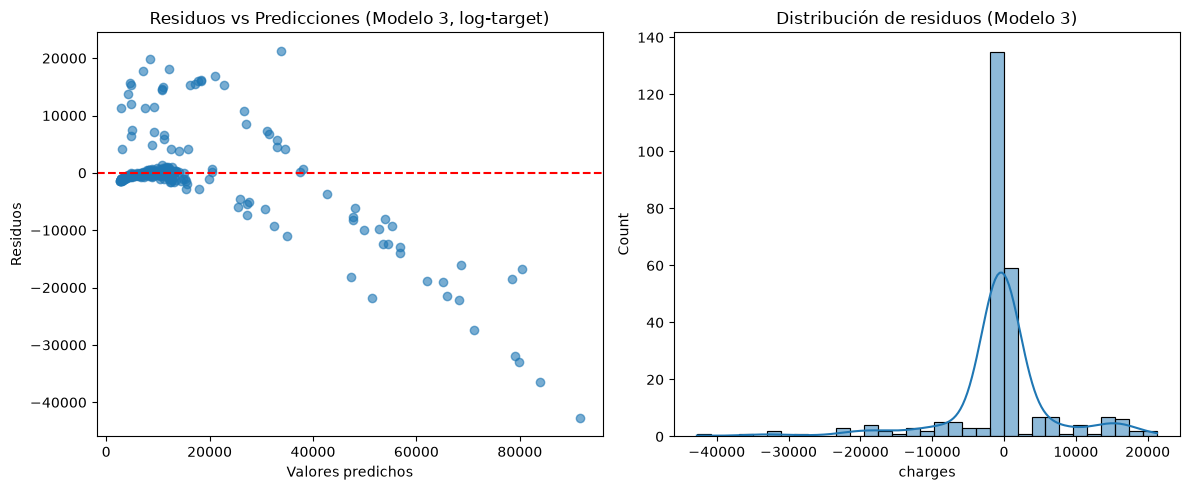

In [22]:
# Residuos del modelo 3 (en escala original)
residuos3 = y_test_real - y_test_pred3

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test_pred3, residuos3, alpha=0.6)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Valores predichos')
axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs Predicciones (Modelo 3, log-target)')

sns.histplot(residuos3, kde=True, ax=axes[1])
axes[1].set_title('Distribución de residuos (Modelo 3)')

plt.tight_layout()
plt.show()

Este modelo resultó ser peor, nos quedaremos con el modelo 2.

**Aplicación**

In [23]:
def predecir_costo(age, sex, bmi, children, smoker, region):
    """
    Predice el costo estimado de seguro para un cliente nuevo.
    sex: 'male' o 'female'
    smoker: 'yes' o 'no'
    region: 'northeast', 'northwest', 'southeast', 'southwest'
    """
    obeso = 1 if bmi >= 30 else 0
    smoker_bin = 1 if smoker == 'yes' else 0
    sex_bin = 1 if sex == 'male' else 0

    fila = {
        'age': age,
        'sex': sex_bin,
        'bmi': bmi,
        'children': children,
        'smoker': smoker_bin,
        'region_northwest': 1 if region == 'northwest' else 0,
        'region_southeast': 1 if region == 'southeast' else 0,
        'region_southwest': 1 if region == 'southwest' else 0,
        'bmi_smoker': bmi * smoker_bin,
        'obeso': obeso,
        'obeso_smoker': obeso * smoker_bin
    }

    X_nuevo = pd.DataFrame([fila])[X_train.columns]  # mismo orden de columnas
    return modelo2.predict(X_nuevo)[0]

# Ejemplos de predicción
print("Cliente 1 (35 años, mujer, BMI 28, 2 hijos, no fumadora, southeast):",
      round(predecir_costo(35, 'female', 28, 2, 'no', 'southeast'), 2))

print("Cliente 2 (35 años, hombre, BMI 33, 2 hijos, fumador, southeast):",
      round(predecir_costo(35, 'male', 33, 2, 'yes', 'southeast'), 2))

Cliente 1 (35 años, mujer, BMI 28, 2 hijos, no fumadora, southeast): 7789.61
Cliente 2 (35 años, hombre, BMI 33, 2 hijos, fumador, southeast): 39290.04


** Conclusiones **
- `smoker` es, por sí sola, la variable más determinante: la mediana de costo de un fumador (~$34,000) es casi 5 veces la de un no fumador (~$7,000).
- El efecto de `bmi` sobre `charges` depende completamente de si el cliente fuma o no (correlación BMI-charges: 0.806 en fumadores vs 0.084 en no fumadores). Esto llevó a construir features de interacción.
- El punto de quiebre real no es un efecto continuo de BMI, sino el umbral clínico de obesidad (BMI ≥ 30): la interacción `obeso_smoker` resultó ser el predictor individual más fuerte del modelo (+14,352 sobre el costo base).
- `sex`, `region` y `children` aportan poco poder predictivo por sí solos.

**Modelado:**
- Se probaron 3 variantes de regresión lineal por defecto (sin optimización de hiperparámetros, según el alcance definido):
  1. Modelo base + interacción continua `bmi_smoker` → Test R² = 0.886
  2. Modelo + interacción por umbral `obeso_smoker` → **Test R² = 0.909** (modelo final)
  3. Modelo con `log(charges)` como target → Test R² = 0.657 (descartado: la retransformación introdujo sesgo, y la relación real es aditiva por segmento, no multiplicativa)
- El modelo final (Modelo 2) logra Test RMSE ≈ 4,085 y Test MAE ≈ 2,276, sin señales de overfitting.

**Conclusión de negocio:**
El perfil de mayor riesgo/costo para la aseguradora es **fumador + obeso (BMI ≥ 30)**, muy por encima de cualquier otra combinación de variables. Este hallazgo permite priorizar la segmentación de clientes y ajustar primas de forma más precisa que con un modelo que solo considere las variables de forma aislada.

**Limitaciones:**
- Persiste un grupo de residuos positivos grandes no explicados por las variables disponibles — probablemente asociados a condiciones médicas preexistentes u otros factores no incluidos en el dataset.